In [1]:
""" Practice Exam 2 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt
from control import margin
from control import tf

<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\o'
<>:39: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_87952\1197538191.py:27: SyntaxWarning: invalid escape sequence '\o'
  plt.text(.3,-20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_87952\1197538191.py:39: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')
C:\Users\Gabriel\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


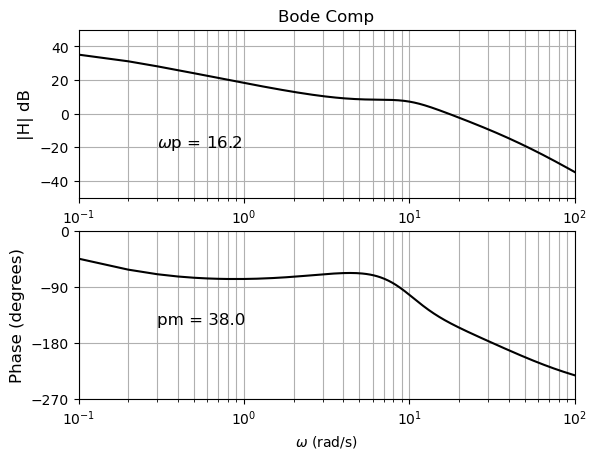

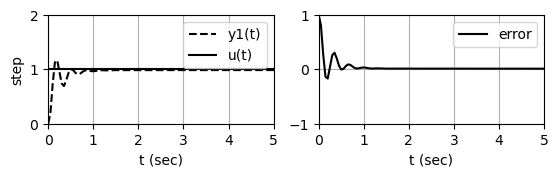

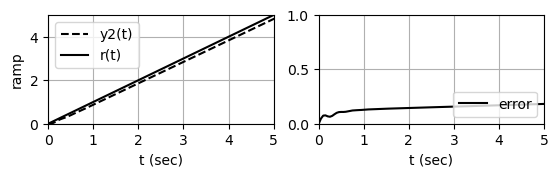

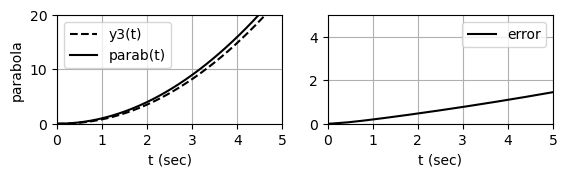

In [2]:
# Use phase lag Gc(s) to reduce the error in the step response
# Increase the pm angle to get rid of overshoot (phase lead)

K = 20833
n1 = [0, 0, 0, 1, 6]
# Expand (s^2+10s+100)(s+25)(s+50) = s^4+85s^3+2100s^2+20000s+125000
d1 = [1, 85, 2100, 20000, 125000]

n2 = [0, 0, 0, 1, 8]
d2 = [0, 0, 0, 1, .1]

n12 = K*np.convolve(n1,n2)
d12 = np.convolve(d1,d2)

num = n12
den = d12

w = np.linspace(0.1,100,num=1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e2, -50, 50])
plt.ylabel('|H| dB',size = 12)
plt.text(.3,-20,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
plt.title('Bode Comp')
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ .1, 1e2, -270,0])
plt.yticks([-270,-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
plt.text(.3,-150,'pm = {}'.format(round(pm,0)),fontsize=12)
plt.grid(which='both')
plt.savefig('H_bode.png',dpi=300)
plt.show()

""" Time portion """

dt = 0.05
NN = 500
TT = np.arange(0,NN*dt,dt)
step = np.zeros(NN)
ramp = np.zeros(NN)
parabola = np.zeros(NN)
errS = np.zeros(NN)
errR = np.zeros(NN)
errP = np.zeros(NN)

for i in range(NN):
    step[i] = 1.0
    ramp[i] = (dt*i)
    parabola[i] = (dt*i)**(2)
    
denCL = np.add(num,den)

t1, y1, x1 = sig.lsim((num,denCL),step,TT)
t2, y2, x2 = sig.lsim((num,denCL),ramp,TT)
t3, y3, x3 = sig.lsim((num,denCL),parabola,TT)

for i in range(NN):
    errS[i] = step[i] - y1[i]
    errR[i] = ramp[i] - y2[i]
    errP[i] = parabola[i] - y3[i]

plt.subplot(321)
plt.plot(TT,y1,'k--',label='y1(t)')
plt.plot(TT,step,'k',label='u(t)')
plt.axis([0,5,0,2])
plt.ylabel('step')
plt.xlabel('t (sec)')
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errS,'k',label='error')
plt.legend()
plt.axis([0,5,-1,1])
plt.xlabel('t (sec)')
plt.grid()
plt.show()

plt.subplot(321)
plt.plot(TT,y2,'k--',label='y2(t)')
plt.plot(TT,ramp,'k',label='r(t)')
plt.xlabel('t (sec)')
plt.ylabel('ramp')
plt.axis([0,5,0,5])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errR,'k',label='error')
plt.legend(loc=4)
plt.xlabel('t (sec)')
plt.axis([0,5,0,1])
plt.grid()
plt.show()

plt.subplot(321)
plt.plot(TT,y3,'k--',label='y3(t)')
plt.plot(TT,parabola,'k',label='parab(t)')
plt.xlabel('t (sec)')
plt.ylabel('parabola')
plt.axis([0,5,0,20])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errP,'k',label='error')
plt.xlabel('t (sec)')
plt.axis([0,5,0,5])
plt.legend()
plt.grid()
plt.show()

In [14]:
""" Phase Lead Calculations """

p_m = 50 *(np.pi/180)
a = (1+np.sin(p_m))/(1-np.sin(p_m))
w_m = -10*np.log10(a)
print("w_m =", w_m)

w_m = -8.778682635948384


In [36]:
# Use this function to find corresponding w
center_freq = 48.75 #rad/s
w_guess = np.interp(center_freq, w, Hmag)
print(w_m, "=", w_guess)

-8.778682635948384 = -8.74754932797399


In [38]:
w_p = np.sqrt(a)*center_freq
w_z = center_freq/np.sqrt(a)
print("w_m =", center_freq, "rad/s")
print("w_p =", w_p, "rad/s")
print("w_z =", w_z, "rad/s")

w_m = 48.75 rad/s
w_p = 133.93952419841284 rad/s
w_z = 17.743548920477366 rad/s


<>:29: SyntaxWarning: invalid escape sequence '\o'
<>:41: SyntaxWarning: invalid escape sequence '\o'
<>:29: SyntaxWarning: invalid escape sequence '\o'
<>:41: SyntaxWarning: invalid escape sequence '\o'
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_87952\3145660934.py:29: SyntaxWarning: invalid escape sequence '\o'
  plt.text(.3,-40,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
C:\Users\Gabriel\AppData\Local\Temp\ipykernel_87952\3145660934.py:41: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('$\omega$ (rad/s)')
C:\Users\Gabriel\anaconda3\Lib\site-packages\scipy\signal\_ltisys.py:600: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


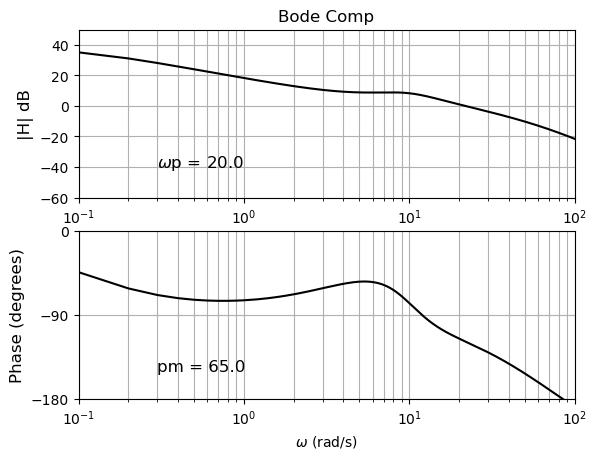

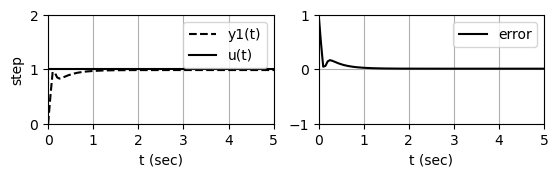

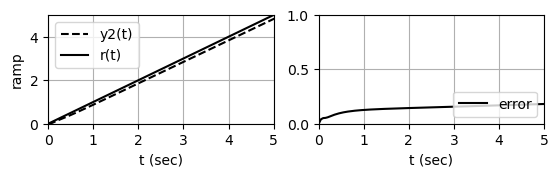

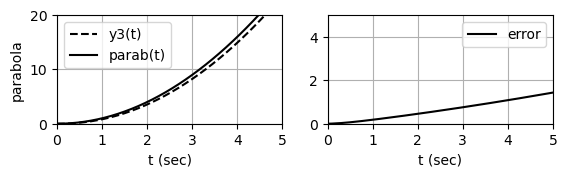

In [40]:
""" Phase Lead Implementation """

K = 20833*(w_p/w_z)
n1 = [0, 0, 0, 1, 6]
d1 = [1, 85, 2100, 20000, 125000]

n2 = [0, 0, 0, 1, 8]
d2 = [0, 0, 0, 1, .1]

n12 = K*np.convolve(n1,n2)
d12 = np.convolve(d1,d2)

n3 = [0, 0, 0, 1, w_z]
d3 = [0, 0, 0, 1, w_p]
n123 = np.convolve(n12,n3)
d123 = np.convolve(d12,d3)
num = n123
den = d123

w = np.linspace(0.1,100,num=1000)
system = sig.lti(num,den)
w, Hmag, Hphase = sig.bode(system,w)
gm, pm, wg, wp = margin(Hmag,Hphase,w)

plt.subplot(211)
plt.semilogx(w,Hmag,'k')
plt.axis([ .1, 1e2, -60, 50])
plt.ylabel('|H| dB',size = 12)
plt.text(.3,-40,'$\omega$p = {}'.format(round(wp,1)),fontsize=12)
plt.title('Bode Comp')
plt.grid(which='both')

for n in range(100):
    if Hphase[n] > 0:
        Hphase[n] = Hphase[n] - 360

plt.subplot(212)
plt.semilogx(w,Hphase,'k')
plt.axis([ .1, 1e2, -180,0])
plt.yticks([-180,-90,0])
plt.xlabel('$\omega$ (rad/s)')
plt.ylabel('Phase (degrees)',size=12)
plt.text(.3,-150,'pm = {}'.format(round(pm,0)),fontsize=12)
plt.grid(which='both')
plt.savefig('H_bode.png',dpi=300)
plt.show()

""" Time portion """

dt = 0.05
NN = 500
TT = np.arange(0,NN*dt,dt)
step = np.zeros(NN)
ramp = np.zeros(NN)
parabola = np.zeros(NN)
errS = np.zeros(NN)
errR = np.zeros(NN)
errP = np.zeros(NN)

for i in range(NN):
    step[i] = 1.0
    ramp[i] = (dt*i)
    parabola[i] = (dt*i)**(2)
    
denCL = np.add(num,den)

t1, y1, x1 = sig.lsim((num,denCL),step,TT)
t2, y2, x2 = sig.lsim((num,denCL),ramp,TT)
t3, y3, x3 = sig.lsim((num,denCL),parabola,TT)

for i in range(NN):
    errS[i] = step[i] - y1[i]
    errR[i] = ramp[i] - y2[i]
    errP[i] = parabola[i] - y3[i]

plt.subplot(321)
plt.plot(TT,y1,'k--',label='y1(t)')
plt.plot(TT,step,'k',label='u(t)')
plt.axis([0,5,0,2])
plt.ylabel('step')
plt.xlabel('t (sec)')
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errS,'k',label='error')
plt.legend()
plt.axis([0,5,-1,1])
plt.xlabel('t (sec)')
plt.grid()
plt.show()

plt.subplot(321)
plt.plot(TT,y2,'k--',label='y2(t)')
plt.plot(TT,ramp,'k',label='r(t)')
plt.xlabel('t (sec)')
plt.ylabel('ramp')
plt.axis([0,5,0,5])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errR,'k',label='error')
plt.legend(loc=4)
plt.xlabel('t (sec)')
plt.axis([0,5,0,1])
plt.grid()
plt.show()

plt.subplot(321)
plt.plot(TT,y3,'k--',label='y3(t)')
plt.plot(TT,parabola,'k',label='parab(t)')
plt.xlabel('t (sec)')
plt.ylabel('parabola')
plt.axis([0,5,0,20])
plt.legend()
plt.grid()

plt.subplot(322)
plt.plot(TT,errP,'k',label='error')
plt.xlabel('t (sec)')
plt.axis([0,5,0,5])
plt.legend()
plt.grid()
plt.show()